# Visualización de datos grillados

En este análisis, nos enfocaremos en la **visualización de campos meteorológicos provenientes de datos grillados** del reanálisis ERA5. El objetivo principal es observar y entender la evolución de un **ciclón atmosférico** desarrollado en la **costa de Perú**, utilizando variables clave para interpretar su dinámica y efectos.

## Variables analizadas:
- **Presión media al nivel del mar (MSLP)**: utilizada para identificar el centro de baja presión asociado al ciclón.
- **Vectores de viento a 10 metros**: permiten visualizar el patrón de circulación del sistema ciclónico.
- **Temperatura del aire a 2 metros**: útil para analizar los contrastes térmicos y posibles advecciones.
- **Precipitación total**: evidencia la distribución espacial de lluvias asociadas al evento.
- **Altura geopotencial a 850 hPa (Z850)**: proporciona información sobre la estructura y ondulación de los sistemas en niveles medios de la atmósfera, siendo clave para identificar vorticidad, advección de altura y soporte dinámico del ciclón.


El análisis se realizará durante el período comprendido **entre el 3 y el 12 de marzo de 2023**, con especial atención a las condiciones atmosféricas observadas a las **18:00 UTC** cada día, momento representativo del desarrollo y evolución del sistema ciclónico.

Estas visualizaciones permiten comprender mejor la estructura del sistema y la interacción entre variables meteorológicas durante un evento de alta relevancia sinóptica.


## Importar librerias

In [1]:
import xarray as xr
import colormaps as cmaps
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd

## Leer datos de ERA5

In [2]:
filename = '../data/ERA5/ERA5_202303_MSLP.nc'
mlsp = xr.open_dataset(filename)/100
mlsp

<xarray.Dataset> Size: 325kB
Dimensions:     (valid_time: 9, latitude: 101, longitude: 89)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 72B 2023-03-04T18:00:00 ... 2023-...
  * latitude    (latitude) float64 808B 5.0 4.75 4.5 4.25 ... -19.5 -19.75 -20.0
  * longitude   (longitude) float64 712B -90.0 -89.75 -89.5 ... -68.25 -68.0
    expver      (valid_time) <U4 144B ...
Data variables:
    msl         (valid_time, latitude, longitude) float32 324kB 1.01e+03 ... ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-07T07:52 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
filename = '../data/ERA5/ERA5_202303_U10.nc'
U10 = xr.open_dataset(filename)/100
filename = '../data/ERA5/ERA5_202303_V10.nc'
V10 = xr.open_dataset(filename)/100


## Análisis de presión y vectores de viento

In [4]:
# --- Define Mercator projection ---
proj = ccrs.Mercator()

Text(0.5, 1.0, '2023-03-11 18UTC')

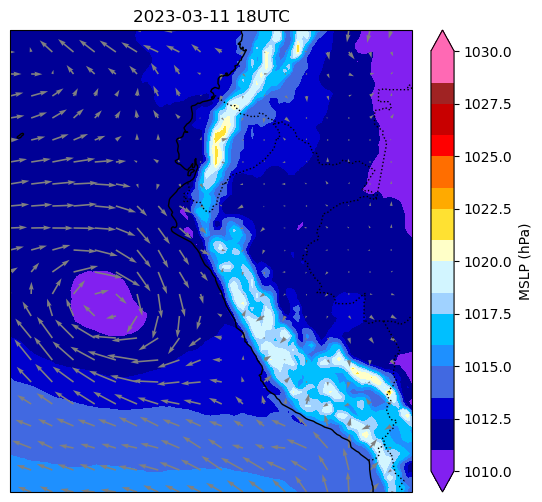

In [5]:
# --- Create figure and axes with Mercator projection ---
# Crea una figura y un eje con tamaño 12x6 pulgadas.
# El eje usa una proyección de mapa especificada en 'proj' (por ejemplo, ccrs.Mercator()).
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': proj})

# Dibuja las líneas de costa en el mapa con una resolución media (50m).
ax.coastlines(resolution='50m')

# Agrega fronteras nacionales al mapa con líneas punteadas.
ax.add_feature(cfeature.BORDERS, linestyle=':')

# --- Opcional: Definir los límites geográficos del mapa ---
# Define el área geográfica que se mostrará: longitud de -90° a -68°, latitud de -20° a 5°.
# Usa la proyección PlateCarree para interpretar correctamente las coordenadas.
ax.set_extent([-90, -68, -20, 5], crs=ccrs.PlateCarree())

# Define los niveles de contorno para el gráfico de presión (MSLP), de 1010 a 1030 hPa con paso de 0.5.
levels = np.arange(1010, 1030.1, 0.5)


# Dibuja un mapa de contornos rellenado (contourf) de la presión al nivel del mar (MSLP),
# usando el campo 'mlsp.msl[8]' para una fecha/hora específica (índice 8).
# El mapa se proyecta desde coordenadas lat/lon con PlateCarree.
time_sel = 7
mslp_plot = ax.contourf(
    mlsp.longitude, mlsp.latitude, mlsp.msl[time_sel],
    levels=levels,
    cmap=cmaps.amwg_blueyellowred,  # Colormap personalizado.
    extend="both",
    transform=ccrs.PlateCarree()
)

# Agrega una barra de colores vertical a la derecha del mapa, para indicar los valores de MSLP.
cbar = plt.colorbar(mslp_plot, ax=ax, orientation='vertical', pad=0.02, label="MSLP (hPa)")

# --- Dibujar vectores de viento (u, v) ---
# Define un paso para reducir la cantidad de flechas de viento, haciendo el gráfico más limpio.
step = 5

# Dibuja vectores de viento en el mapa usando los campos U10 (componente zonal) y V10 (meridional),
# tomando solo cada 5° punto para aligerar la visualización.
# Las flechas se dibujan en gris y escaladas para representar la dirección e intensidad del viento.
ax.quiver(
    U10.longitude[::step], U10.latitude[::step],
    U10.u10[time_sel][::step, ::step], V10.v10[time_sel][::step, ::step],
    transform=ccrs.PlateCarree(),   # Transforma coordenadas lon/lat al sistema de la proyección.
    regrid_shape=20,                # Interpolación espacial opcional (algunas versiones de Cartopy pueden ignorar).
    color='grey', width=0.0040, scale=1.0,  # Estética del vector de viento.
)

date_sel = pd.to_datetime(mlsp.valid_time[time_sel].values).strftime('%Y-%m-%d %H')
ax.set_title(f"{date_sel}UTC")

/tmp/ipykernel_42067/4171467318.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ajustar para no sobreescribir la colorbar


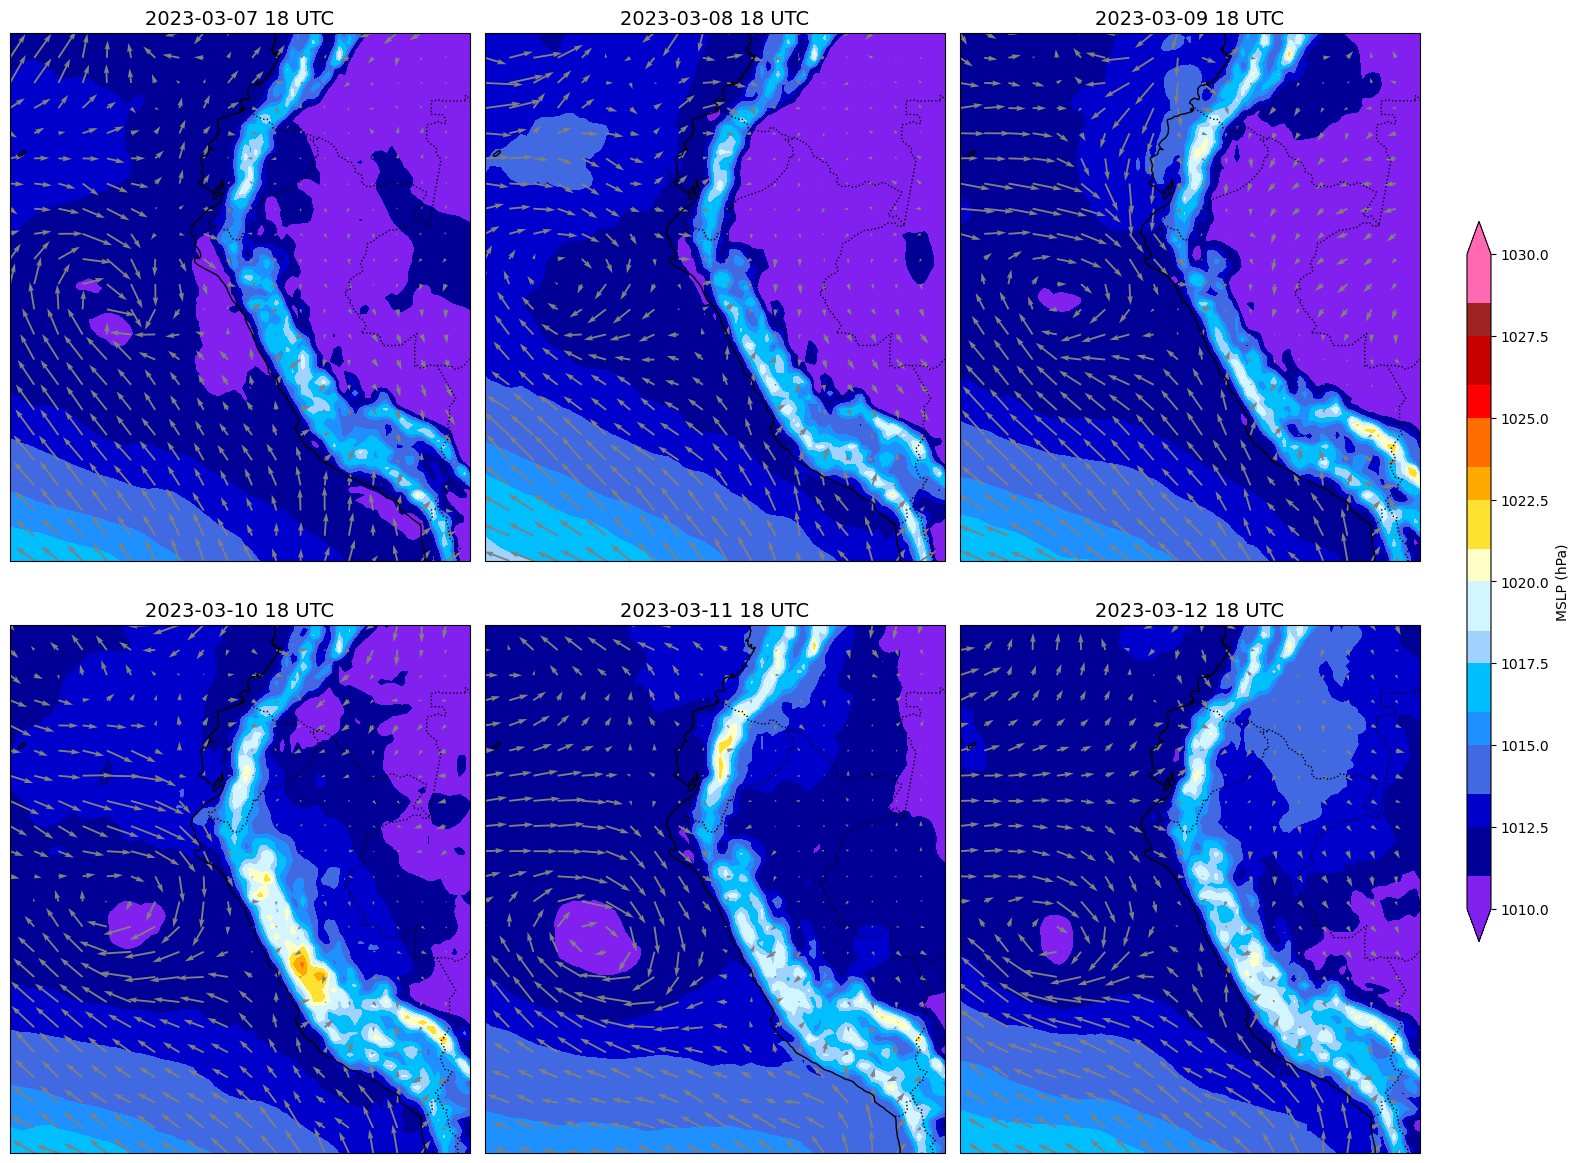

In [7]:
# --- Crear figura y ejes con 6 subplots (2 filas x 3 columnas) ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 12), subplot_kw={'projection': proj})
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

# --- Definir niveles de contorno para MSLP ---
levels = np.arange(1010, 1030.1, 0.5)

# --- Índices de tiempo a graficar ---
time_indices = [3, 4, 5, 6, 7, 8]

# --- Loop sobre los subplots ---
for i, time_sel in enumerate(time_indices):
    ax = axes[i]

    # Dibujar costas y fronteras
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Definir límites geográficos del mapa
    ax.set_extent([-90, -68, -20, 5], crs=ccrs.PlateCarree())

    # Dibujar mapa de contorno (MSLP)
    mslp_plot = ax.contourf(
        mlsp.longitude, mlsp.latitude, mlsp.msl[time_sel],
        levels=levels,
        cmap=cmaps.amwg_blueyellowred,
        extend="both",
        transform=ccrs.PlateCarree()
    )

    # Dibujar vectores de viento
    step = 5
    ax.quiver(
        U10.longitude[::step], U10.latitude[::step],
        U10.u10[time_sel][::step, ::step], V10.v10[time_sel][::step, ::step],
        transform=ccrs.PlateCarree(), regrid_shape=20,
        color='grey', width=0.0040, scale=1.0
    )

    # Título con la fecha
    date_sel = pd.to_datetime(mlsp.valid_time[time_sel].values).strftime('%Y-%m-%d %H')
    ax.set_title(f"{date_sel} UTC", fontsize=14)

# --- Agregar una sola barra de color para todos los subplots ---
# Usar el primer mapeo de contorno (mslp_plot) como referencia
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(mslp_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("MSLP (hPa)")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Ajustar para no sobreescribir la colorbar

fig.savefig(f"../fig/MLSP_202303.png", dpi = 300, facecolor='w', bbox_inches = 'tight', pad_inches = 0.1)

## Análisis de temperatura y Z850

## Análisis de precipitación y Z850